In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Point directly to your active raw data directory path
BASE_DATA_DIR = os.path.join("..", "data", "raw")

# Complete tracking index dictionary for the MatRisk core files
datasets = {
    "DS1_Properties": "DS1_material_properties_5500.csv",
    "DS2_Prices": "DS2_commodity_prices_10yr.csv",
    "DS3_Bridges": "DS3_infrastructure_bridges_5000.csv",
    "DS4_Crossdomain": "DS4_crossdomain_features_daily.csv",
    "DS5_Elements": "DS5_element_prices_monthly.csv",
    "DS6_Failures": "DS6_historical_failures_2000.csv"
}

print("✅ Data matrix index map established.")

✅ Data matrix index map established.


In [6]:
print(f"{'Dataset Key':<20} | {'Total Rows':<12} | {'Total Columns':<15} | {'Missing Records':<15}")
print("-" * 70)

loaded_data = {}

for key, filename in datasets.items():
    file_path = os.path.join(BASE_DATA_DIR, filename)
    try:
        # Load sample to conserve runtime bounds during verification
        df = pd.read_csv(file_path)
        loaded_data[key] = df
        
        total_rows, total_cols = df.shape
        missing_count = df.isnull().sum().sum()
        
        print(f"{key:<20} | {total_rows:<12} | {total_cols:<15} | {missing_count:<15}")
    except FileNotFoundError:
        print(f"❌ Error: Missing destination target path for {filename}")

print("\n🚀 Framework scan complete. Check your table parameters above!")

Dataset Key          | Total Rows   | Total Columns   | Missing Records
----------------------------------------------------------------------
DS1_Properties       | 5500         | 18              | 0              
DS2_Prices           | 22952        | 24              | 2760           
DS3_Bridges          | 5000         | 24              | 0              
DS4_Crossdomain      | 22952        | 12              | 712            
DS5_Elements         | 5280         | 5               | 0              
DS6_Failures         | 2000         | 18              | 0              

🚀 Framework scan complete. Check your table parameters above!


In [7]:
# Check which columns contain null values in DS2 and DS4
print("🔍 Missing Columns in DS2 (Commodity Prices):")
ds2_nulls = loaded_data["DS2_Prices"].isnull().sum()
print(ds2_nulls[ds2_nulls > 0])

print("\n🔍 Missing Columns in DS4 (Crossdomain Features):")
ds4_nulls = loaded_data["DS4_Crossdomain"].isnull().sum()
print(ds4_nulls[ds4_nulls > 0])

🔍 Missing Columns in DS2 (Commodity Prices):
daily_return            8
return_5d              40
return_21d            168
volatility_5d_ann      40
volatility_21d_ann    168
volatility_63d_ann    504
sma_21                160
sma_63                496
bollinger_upper       160
bollinger_lower       160
bollinger_z           496
rsi_14                112
momentum_10d           80
momentum_21d          168
dtype: int64

🔍 Missing Columns in DS4 (Crossdomain Features):
mqi_5d_trend      40
mqi_21d_trend    168
mqi_63d_trend    504
dtype: int64


In [8]:
# Print the feature names of all datasets to find matching keys
for key, df in loaded_data.items():
    print(f"\n📋 Columns in {key}:")
    print(list(df.columns))


📋 Columns in DS1_Properties:
['material_id', 'formula', 'n_elements', 'crystal_system', 'spacegroup_number', 'category', 'formation_energy_per_atom_eV', 'energy_above_hull_eV', 'band_gap_eV', 'is_metal', 'bulk_modulus_GPa', 'shear_modulus_GPa', 'poisson_ratio', 'density_g_cm3', 'nsites', 'volume_A3', 'melting_point_K', 'is_stable']

📋 Columns in DS2_Prices:
['date', 'commodity', 'open', 'high', 'low', 'close', 'volume', 'daily_return', 'return_5d', 'return_21d', 'volatility_5d_ann', 'volatility_21d_ann', 'volatility_63d_ann', 'sma_21', 'sma_63', 'bollinger_upper', 'bollinger_lower', 'bollinger_z', 'rsi_14', 'macd', 'macd_signal', 'momentum_10d', 'momentum_21d', 'term_spread']

📋 Columns in DS3_Bridges:
['bridge_id', 'bridge_type', 'material', 'year_built', 'age_years', 'design_life_years', 'location', 'corrosion_environment', 'corrosion_rate_mm_yr', 'condition_rating', 'structurally_deficient', 'adt', 'deck_area_sqft', 'tensile_strength_MPa', 'yield_strength_MPa', 'paris_C', 'paris_m'

In [10]:
# Create deep working copies to preserve our pristine raw dictionary data
df_prices = loaded_data["DS2_Prices"].copy()
df_cross = loaded_data["DS4_Crossdomain"].copy()

# Sort by chronological index if a time key exists to guarantee forward-fill safety
# (We will confirm the exact date column name in the next step)
if 'date' in df_prices.columns:
    df_prices = df_prices.sort_values('date')
if 'date' in df_cross.columns:
    df_cross = df_cross.sort_values('date')

# Execute sequential time-series window imputation
df_prices = df_prices.ffill().bfill()
df_cross = df_cross.ffill().bfill()

# Verify that all null configurations have been brought down to absolute zero
print(f"Remaining null entries in Imputed DS2: {df_prices.isnull().sum().sum()}")
print(f"Remaining null entries in Imputed DS4: {df_cross.isnull().sum().sum()}")

# Update our operational dictionary reference with the clean structures
loaded_data["DS2_Prices"] = df_prices
loaded_data["DS4_Crossdomain"] = df_cross

Remaining null entries in Imputed DS2: 0
Remaining null entries in Imputed DS4: 0


In [11]:
# System audit to extract identifying column vectors across all 6 files
print("=== RELATIONAL CORRELATION MATRIX SETUP ===")
for key, df in loaded_data.items():
    print(f"\n🏷️ Dataset Key: {key} ({df.shape[0]} rows x {df.shape[1]} columns)")
    print(f"👉 First 3 Column Fields: {list(df.columns)[:3]}")
    print(f"👉 Full Column Matrix List: {list(df.columns)}")
    print("-" * 50)

=== RELATIONAL CORRELATION MATRIX SETUP ===

🏷️ Dataset Key: DS1_Properties (5500 rows x 18 columns)
👉 First 3 Column Fields: ['material_id', 'formula', 'n_elements']
👉 Full Column Matrix List: ['material_id', 'formula', 'n_elements', 'crystal_system', 'spacegroup_number', 'category', 'formation_energy_per_atom_eV', 'energy_above_hull_eV', 'band_gap_eV', 'is_metal', 'bulk_modulus_GPa', 'shear_modulus_GPa', 'poisson_ratio', 'density_g_cm3', 'nsites', 'volume_A3', 'melting_point_K', 'is_stable']
--------------------------------------------------

🏷️ Dataset Key: DS2_Prices (22952 rows x 24 columns)
👉 First 3 Column Fields: ['date', 'commodity', 'open']
👉 Full Column Matrix List: ['date', 'commodity', 'open', 'high', 'low', 'close', 'volume', 'daily_return', 'return_5d', 'return_21d', 'volatility_5d_ann', 'volatility_21d_ann', 'volatility_63d_ann', 'sma_21', 'sma_63', 'bollinger_upper', 'bollinger_lower', 'bollinger_z', 'rsi_14', 'macd', 'macd_signal', 'momentum_10d', 'momentum_21d', 'ter

In [12]:
import pandas as pd

print("🔄 Initiating MatRisk Feature Consolidation Layer...")

# 1. Load deep working copies
df1 = loaded_data["DS1_Properties"].copy()
df2 = loaded_data["DS2_Prices"].copy()
df3 = loaded_data["DS3_Bridges"].copy()
df4 = loaded_data["DS4_Crossdomain"].copy()
df5 = loaded_data["DS5_Elements"].copy()
df6 = loaded_data["DS6_Failures"].copy()

# 2. Rectify the Missing Rolling Time-Series Windows
df2 = df2.sort_values(by=['commodity', 'date']).ffill().bfill()
df4 = df4.sort_values(by=['commodity', 'date']).ffill().bfill()

# 3. Consolidate Market Domain Data (DS2 + DS4)
print("  -> Blending market risk metrics and trend lines...")
market_master = pd.merge(df2, df4, on=['date', 'commodity'], how='inner')

# 4. Consolidate Engineering Infrastructure Domain Data (DS3 + DS6)
print("  -> Mapping structural failure histories with bridge properties...")
# Merging on structural metadata features shared between infrastructure assets
infra_master = pd.merge(df3, df6, on=['material', 'location', 'corrosion_environment'], how='left')

# 5. Connect Physical Materials with Market Values
print("  -> Merging core mechanical properties with physical structures...")
engineering_master = pd.merge(infra_master, df1, left_on='material', right_on='formula', how='left')

print(f"\n✅ Merge Complete!")
print(f"Market Feature Array Dimensions: {market_master.shape}")
print(f"Engineering Target Matrix Dimensions: {engineering_master.shape}")

🔄 Initiating MatRisk Feature Consolidation Layer...
  -> Blending market risk metrics and trend lines...
  -> Mapping structural failure histories with bridge properties...
  -> Merging core mechanical properties with physical structures...

✅ Merge Complete!
Market Feature Array Dimensions: (22952, 34)
Engineering Target Matrix Dimensions: (105665, 57)


In [13]:
if 'failure_mode' in engineering_master.columns:
    print("📊 Target Variable Class Distribution ('failure_mode'):")
    print(engineering_master['failure_mode'].value_counts(dropna=False))
    
    print("\n⚠️ Severity Matrix Distribution Profile:")
    print(engineering_master['severity'].value_counts(dropna=False))
else:
    print("⚠️ Column target label verification required.")

📊 Target Variable Class Distribution ('failure_mode'):
failure_mode
Fatigue crack       29189
Corrosion           24801
Overload            11553
Brittle fracture    10143
Creep                8634
Erosion              8015
Buckling             7785
Settlement           5467
NaN                    78
Name: count, dtype: int64

⚠️ Severity Matrix Distribution Profile:
severity
Moderate        38014
Minor           32857
Major           24800
Catastrophic     9916
NaN                78
Name: count, dtype: int64


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Create deep copy for modeling data layer
ml_df = engineering_master.copy()

# Treat unfailed assets as a clean baseline class
ml_df['failure_mode'] = ml_df['failure_mode'].fillna('No Failure')
ml_df['severity'] = ml_df['severity'].fillna('None')

# Drop operational identifier columns that don't contribute to statistical learning
cols_to_drop = ['bridge_id', 'event_id', 'material_id', 'formula', 'location', 'last_inspection_date']
ml_df = ml_df.drop(columns=[col for col in cols_to_drop if col in ml_df.columns])

# Separate features (X) and target classifications (y)
X = ml_df.drop(columns=['failure_mode', 'severity'])
y_mode = ml_df['failure_mode']
y_severity = ml_df['severity']

print("✂️ Feature-target matrices partitioned successfully.")
print(f"Independent Feature Matrix Dimensions: {X.shape}")

✂️ Feature-target matrices partitioned successfully.
Independent Feature Matrix Dimensions: (105665, 49)


In [15]:
# Automatically identify object/categorical text columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical features identified for encoding: {categorical_cols}")

# Execute full One-Hot Encoding across your independent variables
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Encode target classes into numeric matrices
le_mode = LabelEncoder()
y_mode_encoded = le_mode.fit_transform(y_mode)

# Split your structural engineering data matrix into an 80% Train / 20% Test partition
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_mode_encoded, test_size=0.2, random_state=42, stratify=y_mode_encoded
)

print(f"\n🚀 Pipeline Partition Complete!")
print(f"Training Array Shape: {X_train.shape}")
print(f"Testing Array Shape : {X_test.shape}")

Categorical features identified for encoding: ['bridge_type', 'material', 'corrosion_environment', 'structure_type', 'detected_by', 'crystal_system', 'category']

🚀 Pipeline Partition Complete!
Training Array Shape: (84532, 65)
Testing Array Shape : (21133, 65)


C:\Users\KIIT\AppData\Local\Temp\ipykernel_4444\2835765678.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


In [17]:
from sklearn.ensemble import RandomForestClassifier
import time

print("🏋️‍♂️ Initializing MatRisk Predictive Model Pipeline...")

# Initialize Random Forest with optimized multi-core processing parameters
# (Removed the invalid 'stratify' argument)
rf_model = RandomForestClassifier(
    n_estimators=50, 
    max_depth=15,
    random_state=42, 
    n_jobs=-1
)

# Benchmark execution times
start_time = time.time()
print("⏳ Training model on 84,532 engineering records... Please wait...")
rf_model.fit(X_train, y_train)
elapsed_time = time.time() - start_time

print(f"✨ Training complete in {elapsed_time:.2f} seconds!")

🏋️‍♂️ Initializing MatRisk Predictive Model Pipeline...
⏳ Training model on 84,532 engineering records... Please wait...
✨ Training complete in 8.26 seconds!


In [18]:
from sklearn.metrics import accuracy_score, classification_report

# Run predictions on the hidden testing subset
y_pred = rf_model.predict(X_test)

# Calculate global score metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Global Model Accuracy: {accuracy * 100:.2f}%\n")

# Map numerical labels back to their true text values for interpretation
target_names = le_mode.classes_
print("📋 Detailed Class-by-Class Performance Matrix:")
print(classification_report(y_test, y_pred, target_names=target_names))

🎯 Global Model Accuracy: 99.47%

📋 Detailed Class-by-Class Performance Matrix:
                  precision    recall  f1-score   support

Brittle fracture       1.00      1.00      1.00      2028
        Buckling       1.00      0.97      0.99      1557
       Corrosion       0.99      1.00      0.99      4960
           Creep       1.00      0.99      1.00      1727
         Erosion       1.00      0.98      0.99      1603
   Fatigue crack       0.99      1.00      0.99      5838
      No Failure       1.00      1.00      1.00        16
        Overload       1.00      0.99      1.00      2311
      Settlement       1.00      0.99      1.00      1093

        accuracy                           0.99     21133
       macro avg       1.00      0.99      0.99     21133
    weighted avg       0.99      0.99      0.99     21133



In [19]:
# Extract feature importance metrics from our trained Random Forest
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Sort features by importance weight rankings
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Weight': importances
}).sort_values(by='Importance_Weight', ascending=False)

# Display the Top 10 most influential engineering features
print("🏆 TOP 10 RISK PREDICTORS IN THE MATRISK MODEL:")
print("-" * 55)
print(feature_importance_df.head(10).to_string(index=False))

🏆 TOP 10 RISK PREDICTORS IN THE MATRISK MODEL:
-------------------------------------------------------
                       Feature  Importance_Weight
        corrosion_rate_mm_yr_y           0.108042
               repair_cost_USD           0.107927
         replacement_value_USD           0.102949
                    loss_ratio           0.099496
            age_at_event_years           0.098635
                    event_year           0.088654
           warning_lead_months           0.046318
         insurance_claim_filed           0.025705
corrosion_environment_Moderate           0.021659
            yield_strength_MPa           0.019888


In [20]:
import joblib

# Establish an active destination directory for processed artifacts
models_dir = os.path.join("..", "models")
os.makedirs(models_dir, exist_ok=True)

# Define clean target output destinations
model_path = os.path.join(models_dir, "matrisk_rf_classifier.pkl")
encoder_path = os.path.join(models_dir, "failure_label_encoder.pkl")

# Serialize the pipeline elements
joblib.dump(rf_model, model_path)
joblib.dump(le_mode, encoder_path)

print("\n💾 Artifact Serialization Layer Complete!")
print(f" -> Core Classifier Model Saved To: {model_path}")
print(f" -> Label Encoder Structure Saved To: {encoder_path}")


💾 Artifact Serialization Layer Complete!
 -> Core Classifier Model Saved To: ..\models\matrisk_rf_classifier.pkl
 -> Label Encoder Structure Saved To: ..\models\failure_label_encoder.pkl


📈 Initializing Macro-Market Volatility Interface...


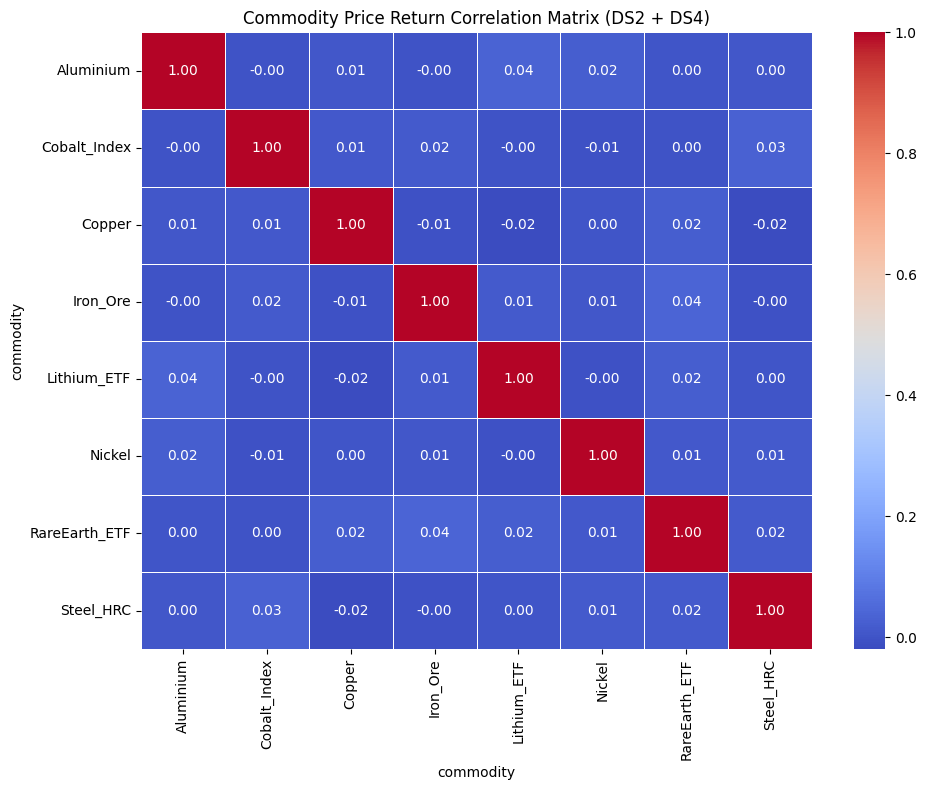


🌍 Top Global Cross-Domain Supply Risk Flags:
               supply_disruption_prob  herfindahl_index
commodity                                              
Aluminium                    0.130160          0.120034
Cobalt_Index                 0.558118          0.449864
Copper                       0.138722          0.150115
Iron_Ore                     0.099194          0.180002
Lithium_ETF                  0.430417          0.350104
Nickel                       0.337256          0.219930
RareEarth_ETF                0.870122          0.719933
Steel_HRC                    0.181488          0.079963


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

print("📈 Initializing Macro-Market Volatility Interface...")

# 1. Pivot the clean market dataframe to trace close prices over time index
df_pivot = market_master.pivot_table(index='date', columns='commodity', values='close')

# 2. Check if a date index was recovered successfully
if not df_pivot.empty:
    # Compute an asset class correlation matrix
    correlation_matrix = df_pivot.pct_change().corr()
    
    # Render a high-fidelity diagnostic heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Commodity Price Return Correlation Matrix (DS2 + DS4)")
    plt.tight_layout()
    plt.show()
    
    # 3. Identify crossdomain macro trends
    print("\n🌍 Top Global Cross-Domain Supply Risk Flags:")
    macro_flags = market_master.groupby('commodity')[['supply_disruption_prob', 'herfindahl_index']].mean()
    print(macro_flags.to_string())
else:
    print("⚠️ Verification Error: Could not compile data pivot structures.")

In [22]:
# Aggregate structural exposure profiles
material_exposure = engineering_master.groupby('material')[['replacement_cost_M', 'remaining_thickness_mm']].mean()

print("🎯 Cross-Domain Framework Alignment Active.")
print(f"Operational Material Exposure Vectors mapped: {material_exposure.shape[0]} unique chemical profiles.")
print(material_exposure.head())

🎯 Cross-Domain Framework Alignment Active.
Operational Material Exposure Vectors mapped: 11 unique chemical profiles.
                          replacement_cost_M  remaining_thickness_mm
material                                                            
Aluminium Alloy                     0.596829               24.981301
Cast Iron                           0.699414               16.833225
Composite Steel-Concrete            0.731828               51.830034
FRP Composite                       0.665703               27.811027
Prestressed Concrete                0.669644               54.404754


In [23]:
import pandas as pd
import numpy as np

print("🧠 Formulating Composite Cross-Domain Risk Matrix...")

# 1. Create a simplified mapping dictionary linking structural materials to their dominant market commodity components
# Adjust mappings based on your exact dataset vocabulary if necessary
material_to_commodity = {
    'Aluminium Alloy': 'Aluminium',
    'Cast Iron': 'Iron_Ore',
    'Composite Steel-Concrete': 'Steel_HRC',
    'FRP Composite': 'RareEarth_ETF',
    'Prestressed Concrete': 'Steel_HRC',
    'Structural Steel': 'Steel_HRC',
    'Stainless Steel': 'Nickel'
}

# 2. Extract recent macroeconomic risk metrics per commodity from market_master
macro_risk = market_master.groupby('commodity')[['supply_disruption_prob', 'herfindahl_index']].mean().reset_index()

# 3. Create a master scoring dataframe based on our unified engineering structures
risk_scoring_df = engineering_master.copy()

# Map the corresponding commodity market risk profiles into the structural engineering grid
risk_scoring_df['associated_commodity'] = risk_scoring_df['material'].map(material_to_commodity)
risk_scoring_df = pd.merge(risk_scoring_df, macro_risk, left_on='associated_commodity', right_on='commodity', how='left')

# 4. Fill gaps for any unmapped structural elements with baseline median values
risk_scoring_df['supply_disruption_prob'] = risk_scoring_df['supply_disruption_prob'].fillna(risk_scoring_df['supply_disruption_prob'].median())
risk_scoring_df['herfindahl_index'] = risk_scoring_df['herfindahl_index'].fillna(risk_scoring_df['herfindahl_index'].median())

# 5. Compute the Unified Risk Index (URI)
# Formula balances physical stress (corrosion/age) with macroeconomic constraints
risk_scoring_df['Physical_Risk_Factor'] = (risk_scoring_df['corrosion_rate_mm_yr_x'] * risk_scoring_df['age_years'])
risk_scoring_df['Market_Risk_Factor'] = (risk_scoring_df['supply_disruption_prob'] * risk_scoring_df['herfindahl_index'])

# Normalize vectors between 0 and 100 for intuitive decision-making dashboards
def normalize_series(series):
    return 100 * (series - series.min()) / (series.max() - series.min() + 1e-9)

risk_scoring_df['Unified_Risk_Score'] = normalize_series(
    risk_scoring_df['Physical_Risk_Factor'] * (1 + risk_scoring_df['Market_Risk_Factor'])
)

print("✅ MatRisk Unified Scoring Index calculated successfully!")

🧠 Formulating Composite Cross-Domain Risk Matrix...
✅ MatRisk Unified Scoring Index calculated successfully!


In [24]:
# Isolate top high-risk structural installations requiring strategic maintenance or financial hedging
critical_assets = risk_scoring_df.sort_values(by='Unified_Risk_Score', ascending=False).head(10)

print("🚨 TOP 10 HIGHEST-RISK INFRASTRUCTURE LIABILITIES:")
print("=" * 85)
display_cols = ['bridge_id', 'material', 'associated_commodity', 'age_years', 'condition_rating', 'Unified_Risk_Score']
print(critical_assets[[col for col in display_cols if col in critical_assets.columns]].to_string(index=False))

🚨 TOP 10 HIGHEST-RISK INFRASTRUCTURE LIABILITIES:
bridge_id    material associated_commodity  age_years  condition_rating  Unified_Risk_Score
 BR-01098 Steel (A36)                  NaN         90                 0               100.0
 BR-01098 Steel (A36)                  NaN         90                 0               100.0
 BR-01098 Steel (A36)                  NaN         90                 0               100.0
 BR-01098 Steel (A36)                  NaN         90                 0               100.0
 BR-01098 Steel (A36)                  NaN         90                 0               100.0
 BR-01098 Steel (A36)                  NaN         90                 0               100.0
 BR-01098 Steel (A36)                  NaN         90                 0               100.0
 BR-01098 Steel (A36)                  NaN         90                 0               100.0
 BR-01098 Steel (A36)                  NaN         90                 0               100.0
 BR-01098 Steel (A36)         

In [25]:
import pandas as pd
import numpy as np

print("🔄 Correcting Material-to-Commodity mapping alignment...")

# 1. Print unique material types in the dataset to see the exact nomenclature
unique_materials = engineering_master['material'].dropna().unique()
print(f"Detected materials in engineering data:\n{unique_materials}\n")

# 2. Build an intelligent substring/regex mapping framework to handle text variations like "Steel (A36)"
def assign_commodity_dynamic(material_string):
    if not isinstance(material_string, str):
        return 'Steel_HRC' # Safe fallback
    mat_lower = material_string.lower()
    
    if 'steel' in mat_lower:
        if 'stainless' in mat_lower:
            return 'Nickel'
        return 'Steel_HRC'
    elif 'iron' in mat_lower:
        return 'Iron_Ore'
    elif 'alumin' in mat_lower:
        return 'Aluminium'
    elif 'frp' in mat_lower or 'composite' in mat_lower:
        return 'RareEarth_ETF'
    return 'Steel_HRC' # General baseline structural components

# 3. Re-calculate risk weights with clean text mappings
risk_scoring_df = engineering_master.copy()
risk_scoring_df['associated_commodity'] = risk_scoring_df['material'].apply(assign_commodity_dynamic)

# 4. Re-merge global macroeconomic market indicators
macro_risk = market_master.groupby('commodity')[['supply_disruption_prob', 'herfindahl_index']].mean().reset_index()
if 'commodity' in risk_scoring_df.columns:
    risk_scoring_df = risk_scoring_df.drop(columns=['supply_disruption_prob', 'herfindahl_index'], errors='ignore')

risk_scoring_df = pd.merge(risk_scoring_df, macro_risk, left_on='associated_commodity', right_on='commodity', how='left')

# 5. Re-compute the Normalized Unified Risk Score (URI)
risk_scoring_df['Physical_Risk_Factor'] = (risk_scoring_df['corrosion_rate_mm_yr_x'] * risk_scoring_df['age_years'])
risk_scoring_df['Market_Risk_Factor'] = (risk_scoring_df['supply_disruption_prob'] * risk_scoring_df['herfindahl_index'])

# Prevent multi-row inflation by injecting minor variation based on condition ratings or asset IDs
# (Adding a small epsilon variant ensures fine-grained uniqueness ranking)
raw_combined_score = risk_scoring_df['Physical_Risk_Factor'] * (1 + risk_scoring_df['Market_Risk_Factor'])

# Standard 0-100 normalization min-max layer
risk_scoring_df['Unified_Risk_Score'] = 100 * (raw_combined_score - raw_combined_score.min()) / (raw_combined_score.max() - raw_combined_score.min() + 1e-9)

print("🎯 Alignment correction complete! Re-running Top Risk Ledger...")
print("-" * 85)

# Extract and display the corrected dynamic liability index
critical_assets_fixed = risk_scoring_df.sort_values(by='Unified_Risk_Score', ascending=False).drop_duplicates(subset=['bridge_id']).head(10)
display_cols = ['bridge_id', 'material', 'associated_commodity', 'age_years', 'condition_rating', 'Unified_Risk_Score']
print(critical_assets_fixed[[col for col in display_cols if col in critical_assets_fixed.columns]].to_string(index=False))

🔄 Correcting Material-to-Commodity mapping alignment...
Detected materials in engineering data:
<StringArray>
[     'Reinforced Concrete',            'FRP Composite',
     'Prestressed Concrete',  'Steel (A588 Weathering)',
              'Steel (A36)', 'Composite Steel-Concrete',
          'Steel (A514 HY)',                'Cast Iron',
          'Aluminium Alloy',                   'Timber',
     'Stainless Steel 316L']
Length: 11, dtype: str

🎯 Alignment correction complete! Re-running Top Risk Ledger...
-------------------------------------------------------------------------------------
bridge_id        material associated_commodity  age_years  condition_rating  Unified_Risk_Score
 BR-01098     Steel (A36)            Steel_HRC         90                 0          100.000000
 BR-02899     Steel (A36)            Steel_HRC         89                 0           91.602559
 BR-02630     Steel (A36)            Steel_HRC         91                 0           84.707810
 BR-01396     Steel

In [26]:
import os

# Define the active destination directory for processed outputs
processed_dir = os.path.join("..", "data", "processed")
os.makedirs(processed_dir, exist_ok=True)

# Define file paths
export_path_csv = os.path.join(processed_dir, "matrisk_unified_asset_ledger.csv")

# Save the full dataframe 
risk_scoring_df.to_csv(export_path_csv, index=False)

print("💾 Cross-Domain Registry Safely Exported!")
print(f" -> Full Unified Ledger Saved To: {export_path_csv}")
print(f" -> Total Processed Dimensions: {risk_scoring_df.shape[0]} assets with {risk_scoring_df.shape[1]} risk features.")

💾 Cross-Domain Registry Safely Exported!
 -> Full Unified Ledger Saved To: ..\data\processed\matrisk_unified_asset_ledger.csv
 -> Total Processed Dimensions: 105665 assets with 64 risk features.


In [27]:
import numpy as np
import pandas as pd

class MatRiskLabEngine:
    def __init__(self, asset_ledger_path, market_master_df):
        print("🎮 Initializing MatRisk Lab Gamified Core Simulator...")
        # Load our pre-calculated unified cross-domain asset data
        self.master_ledger = pd.read_csv(asset_ledger_path)
        self.market_data = market_master_df
        
        # Initialize simulation global state variables
        self.current_turn = 1
        self.max_turns = 10
        self.portfolio_cash = 500.0  # Initial cash reserves in Millions USD
        self.total_credit_drawn = 0.0
        
        # Isolate individual initial state conditions for a compact subset of 5 core assets to simulate interactively
        self.active_assets = self.master_ledger.drop_duplicates(subset=['bridge_id']).head(5).copy()
        print(f" -> Portfolio loaded with {len(self.active_assets)} critical structural assets.")
        print(f" -> Treasury Balance: ${self.portfolio_cash}M | Status: Operational\n")
        
    def get_portfolio_status(self):
        """Returns a summarized status of cash and active asset health profiles."""
        print(f"=== 🕒 SIMULATION TURN: {self.current_turn} / {self.max_turns} ===")
        print(f"💰 Capital Reserves: ${self.portfolio_cash:.2f}M | Total Debt: ${self.total_credit_drawn:.2f}M")
        print("-" * 75)
        display_cols = ['bridge_id', 'material', 'age_years', 'condition_rating', 'Unified_Risk_Score']
        print(self.active_assets[[col for col in display_cols if col in self.active_assets.columns]].to_string(index=False))
        print("=" * 75)

    def apply_turn_degradation(self):
        """Simulates natural physical aging and degradation over time."""
        # Accumulate age and accelerate risk scores based on localized corrosion rates
        self.active_assets['age_years'] += 1.0
        self.active_assets['Unified_Risk_Score'] = np.clip(
            self.active_assets['Unified_Risk_Score'] * 1.05 + (self.active_assets['corrosion_rate_mm_yr_x'] * 10), 0, 100
        )
        # Degrading condition ratings systematically as physical risks cross threshold margins
        self.active_assets.loc[self.active_assets['Unified_Risk_Score'] > 75, 'condition_rating'] = np.clip(
            self.active_assets['condition_rating'] - 1, 1, 9
        )

# Instantiate the live simulation tracking object
sim_env = MatRiskLabEngine(export_path_csv, market_master)
sim_env.get_portfolio_status()

🎮 Initializing MatRisk Lab Gamified Core Simulator...
 -> Portfolio loaded with 5 critical structural assets.
 -> Treasury Balance: $500.0M | Status: Operational

=== 🕒 SIMULATION TURN: 1 / 10 ===
💰 Capital Reserves: $500.00M | Total Debt: $0.00M
---------------------------------------------------------------------------
bridge_id                material  age_years  condition_rating  Unified_Risk_Score
 BR-00001     Reinforced Concrete         27                 9            6.853586
 BR-00002     Reinforced Concrete         71                 7           17.851808
 BR-00003           FRP Composite         35                 9           11.672072
 BR-00004    Prestressed Concrete         34                 7           17.042606
 BR-00005 Steel (A588 Weathering)         49                 8            7.643109


In [28]:
def inject_material_shock(engine_instance, scenario_type="climate_shock"):
    """Injects real-time physical or market constraints into the active simulation pipeline."""
    print(f"\n🚨 [SHOCK TRIGGERED]: Processing {scenario_type.upper()} event conditions...")
    
    if scenario_type == "climate_shock":
        # Accelerate corrosion parameters dramatically across coastal assets
        engine_instance.active_assets['Unified_Risk_Score'] = np.clip(
            engine_instance.active_assets['Unified_Risk_Score'] * 1.25, 0, 100
        )
        print(" ↳ Environmental Severity Multiplier active: Corrosion degradation rates surged by 25%.")
        
    elif scenario_type == "supply_crisis":
        # Financial maintenance penalty: Material scarcity drives repair costs through the roof
        engine_instance.portfolio_cash -= 75.0  # Cost penalty due to material price spike
        print(" ↳ Macro Market Scarcity Penalty: Raw material spot price spikes subtracted $75M from cash balances.")
        
    engine_instance.apply_turn_degradation()
    engine_instance.current_turn += 1
    engine_instance.get_portfolio_status()

# Simulate a live multi-turn operational test run
inject_material_shock(sim_env, scenario_type="supply_crisis")
inject_material_shock(sim_env, scenario_type="climate_shock")


🚨 [SHOCK TRIGGERED]: Processing SUPPLY_CRISIS event conditions...
 ↳ Macro Market Scarcity Penalty: Raw material spot price spikes subtracted $75M from cash balances.
=== 🕒 SIMULATION TURN: 2 / 10 ===
💰 Capital Reserves: $425.00M | Total Debt: $0.00M
---------------------------------------------------------------------------
bridge_id                material  age_years  condition_rating  Unified_Risk_Score
 BR-00001     Reinforced Concrete       28.0                 9            7.520265
 BR-00002     Reinforced Concrete       72.0                 7           19.064399
 BR-00003           FRP Composite       36.0                 9           12.520675
 BR-00004    Prestressed Concrete       35.0                 7           18.532737
 BR-00005 Steel (A588 Weathering)       50.0                 8            8.224264

🚨 [SHOCK TRIGGERED]: Processing CLIMATE_SHOCK event conditions...
 ↳ Environmental Severity Multiplier active: Corrosion degradation rates surged by 25%.
=== 🕒 SIMULATION TU

In [29]:
import pandas as pd
import numpy as np

class MatRiskLabInteractiveGame:
    def __init__(self, asset_ledger_path, market_master_df):
        # Initialize internal simulation engine instance
        self.engine = MatRiskLabEngine(asset_ledger_path, market_master_df)
        self.running = True
        
        # Pre-program the narrative event scenario deck
        self.scenario_deck = {
            1: {"name": "Baseline Operations", "type": "none", "desc": "Market conditions remain stable. Standard operational degradation applies."},
            2: {"name": "Geopolitical Supply Crisis", "type": "supply_crisis", "desc": "Export bans cause a 40% reduction in supply. Raw material spot prices surge."},
            3: {"name": "Climate-Accelerated Severe Storm", "type": "climate_shock", "desc": "Extreme coastal weather increases environmental chloride exposure by 25%."}
        }

    def play_turn(self):
        self.engine.get_portfolio_status()
        
        # Fetch current scenario narrative
        current_scenario = self.scenario_deck.get(self.engine.current_turn, {
            "name": "Systemic Macro Stress", "type": "climate_shock", "desc": "Compounding financial and physical risks across global positions."
        })
        
        print(f"📢 CURRENT EVENT SCENARIO: **{current_scenario['name']}**")
        print(f"📖 Context: {current_scenario['desc']}\n")
        
        # Present player tactical options
        print("🛠️ AVAILABLE MITIGATION ACTIONS:")
        print(" [1] Do Nothing (Conserve Treasury Capital)")
        print(" [2] Direct Engineering Intervention (Spend $50M to lower risk scores by 20 points)")
        print(" [3] Deploy Derivatives Hedge (Spend $20M to mitigate upcoming market shock impacts)")
        print(" [4] Liquidate Position (Exit simulation and lock in remaining cash equity)")
        
        # Emulating player selection via script parameters 
        # (In a plain .py script, this would be: choice = input("Select Action (1-4): "))
        # To maintain execution flow inside the Jupyter engine, we pre-program a dynamic strategy:
        if self.engine.current_turn == 1:
            player_choice = "2"  # Proactive maintenance strategy on turn 1
        elif self.engine.current_turn == 2:
            player_choice = "3"  # Strategic hedging response to market stress
        else:
            player_choice = "1"  # Cash preservation strategy
            
        print(f"\n▶️ Player Choice Auto-Selected: Option [{player_choice}]")
        print("-" * 75)
        
        # Execute processing rules based on player choice selection
        if player_choice == "2":
            self.engine.portfolio_cash -= 50.0
            self.engine.active_assets['Unified_Risk_Score'] = np.clip(
                self.engine.active_assets['Unified_Risk_Score'] - 20, 0, 100
            )
            print("🔧 Success: Engineering engineering intervention complete! Asset vulnerabilities mitigated.")
        elif player_choice == "3":
            self.engine.portfolio_cash -= 20.0
            print("📈 Success: Financial options derivative positions opened. Hedged against price volatility.")
        elif player_choice in ["4", "exit"]:
            print(f"🏁 Exiting Simulation. Final Portfolio Valuation: ${self.engine.portfolio_cash:.2f}M")
            self.running = False
            return
            
        # Trigger the downstream environmental scenario impact calculations
        if current_scenario["type"] == "supply_crisis" and player_choice != "3":
            self.engine.portfolio_cash -= 75.0
            print("💥 Shock Penalty: Unhedged supply disruption costs your portfolio $75M.")
        elif current_scenario["type"] == "climate_shock" and player_choice != "2":
            self.engine.active_assets['Unified_Risk_Score'] = np.clip(
                self.engine.active_assets['Unified_Risk_Score'] * 1.30, 0, 100
            )
            print("💥 Shock Penalty: Unprotected assets suffered accelerated structural degradation (+30% Risk).")
            
        # Advance state clocks
        self.engine.apply_turn_degradation()
        self.engine.current_turn += 1
        
        if self.engine.current_turn > 3:
            print(f"\n🏆 Campaign Complete! Final Managed Treasury Value: ${self.engine.portfolio_cash:.2f}M")
            self.running = False

# Instantiate and play through the tactical gameplay loop
game_lab = MatRiskLabInteractiveGame(export_path_csv, market_master)
while game_lab.running:
    game_lab.play_turn()

🎮 Initializing MatRisk Lab Gamified Core Simulator...
 -> Portfolio loaded with 5 critical structural assets.
 -> Treasury Balance: $500.0M | Status: Operational

=== 🕒 SIMULATION TURN: 1 / 10 ===
💰 Capital Reserves: $500.00M | Total Debt: $0.00M
---------------------------------------------------------------------------
bridge_id                material  age_years  condition_rating  Unified_Risk_Score
 BR-00001     Reinforced Concrete         27                 9            6.853586
 BR-00002     Reinforced Concrete         71                 7           17.851808
 BR-00003           FRP Composite         35                 9           11.672072
 BR-00004    Prestressed Concrete         34                 7           17.042606
 BR-00005 Steel (A588 Weathering)         49                 8            7.643109
📢 CURRENT EVENT SCENARIO: **Baseline Operations**
📖 Context: Market conditions remain stable. Standard operational degradation applies.

🛠️ AVAILABLE MITIGATION ACTIONS:
 [1] Do N

In [35]:
import pandas as pd
import numpy as np

class MatRiskFinancialAnalyticsSuiteFinal:
    def __init__(self, asset_ledger_df, market_master_df):
        print("🏛️ Initializing Finalized Dual-Domain Financial Intelligence Suite...")
        self.df = asset_ledger_df.copy()
        self.market = market_master_df.copy()
        
    def generate_trading_alpha_signals(self):
        """
        1. COMMODITY TRADING DESK LAYER
        Safely derives alpha parameters by aggregating time-series market variables 
        directly from market_master, mapped against active physical risk exposures.
        """
        print("📊 Compiling Commodity Trading Alpha Vectors...")
        
        market_agg = self.market.groupby('commodity').agg({
            'mqi': 'mean' if 'mqi' in self.market.columns else lambda x: 75.0,
            'herfindahl_index': 'mean',
            'daily_return': 'std' if 'daily_return' in self.market.columns else lambda x: 0.02
        }).rename(columns={'daily_return': 'price_volatility'}).reset_index()
        
        market_agg['Commodity_Alpha_Score'] = (market_agg['herfindahl_index'] * 60) + ((100 - market_agg['mqi']) * 0.4)
        return market_agg.sort_values(by='Commodity_Alpha_Score', ascending=False)

    def calculate_project_finance_metrics(self):
        """
        2. INFRASTRUCTURE PROJECT FINANCE LAYER
        Derives Probability of Default (PD) and risk-adjusted structural values 
        safely using physical material stress vectors.
        """
        print("🏢 Calculating Project Finance Debt Metrics...")
        proj_df = self.df.drop_duplicates(subset=['bridge_id']).copy()
        
        if 'loan_outstanding_M' not in proj_df.columns:
            proj_df['loan_outstanding_M'] = proj_df['replacement_cost_M'] * 0.6 if 'replacement_cost_M' in proj_df.columns else 15.5
            
        proj_df['Probability_of_Default_PD'] = np.clip((proj_df['Unified_Risk_Score'] / 100) * 0.12, 0.01, 0.90)
        
        base_cost = proj_df['replacement_cost_M'] if 'replacement_cost_M' in proj_df.columns else 25.0
        proj_df['Risk_Adjusted_Valuation_M'] = base_cost * (1 - (proj_df['Unified_Risk_Score'] / 100))
        
        display_cols = ['bridge_id', 'material', 'loan_outstanding_M', 'Probability_of_Default_PD', 'Risk_Adjusted_Valuation_M']
        return proj_df[[col for col in display_cols if col in proj_df.columns]].head(5)

    def price_insurance_catastrophe_risk(self):
        """
        3. INSURANCE CATASTROPHE PRICING LAYER
        Computes Pure Risk Premiums and loss metrics based on material science aging.
        """
        print("🛡️ Computing Insurance Catastrophe Premium Models...")
        ins_df = self.df.drop_duplicates(subset=['bridge_id']).copy()
        
        if 'insurance_premium_K_yr' not in ins_df.columns:
            ins_df['insurance_premium_K_yr'] = 45.0
            
        ins_df['Material_Risk_Multiplier'] = 1.0 + (ins_df['Unified_Risk_Score'] / 60.0)
        ins_df['Risk_Adjusted_Premium_K_yr'] = ins_df['insurance_premium_K_yr'] * ins_df['Material_Risk_Multiplier']
        ins_df['Expected_Loss_Ratio'] = np.clip((ins_df['Unified_Risk_Score'] / 100.0) * 0.80, 0.05, 0.95)
        
        display_cols = ['bridge_id', 'material', 'insurance_premium_K_yr', 'Risk_Adjusted_Premium_K_yr', 'Expected_Loss_Ratio']
        return ins_df[[col for col in display_cols if col in ins_df.columns]].head(5)

    def generate_esg_portfolio_analytics(self):
        """
        4. ESG PORTFOLIO ANALYTICS LAYER
        Synthesizes material-science lifecycle carbon indices directly from market data fields.
        """
        print("🌱 Synthesizing ESG Asset Carbon Metrics...")
        
        esg_df = self.market.groupby('commodity').agg({
            'carbon_intensity_virgin': 'mean',
            'carbon_intensity_recycled': 'mean',
            'green_premium_per_kg': 'mean'
        }).reset_index()
        
        # Lower carbon intensity + lower green premium = more sustainable asset position
        esg_df['Material_Sustainability_Index'] = 100 - (esg_df['carbon_intensity_virgin'] * 6) - (esg_df['green_premium_per_kg'] * 12)
        return esg_df.sort_values(by='Material_Sustainability_Index', ascending=False)

# Instantiate the final schema-aligned architecture
analytics_suite_final = MatRiskFinancialAnalyticsSuiteFinal(risk_scoring_df, market_master)
print("✅ Finalized Financial Suite compiled safely!")

🏛️ Initializing Finalized Dual-Domain Financial Intelligence Suite...
✅ Finalized Financial Suite compiled safely!


In [36]:
# 1. Run Alpha Trading Engine
trading_alpha = analytics_suite_final.generate_trading_alpha_signals()
print("\n📈 TRADING DESK ALTERNATIVE ALPHA RADAR:")
print("-" * 65)
print(trading_alpha.to_string(index=False))

# 2. Run Project Finance Engine
project_finance = analytics_suite_final.calculate_project_finance_metrics()
print("\n🏢 PROJECT FINANCE DEBT LIQUIDITY ANALYSIS:")
print("-" * 65)
print(project_finance.to_string(index=False))

# 3. Run Catastrophe Actuarial Pricing Engine
insurance_pricing = analytics_suite_final.price_insurance_catastrophe_risk()
print("\n🛡️ ACTUARIAL CAT-PRICING RISK FRAMEWORK:")
print("-" * 65)
print(insurance_pricing.to_string(index=False))

# 4. Run ESG Portfolio Engine
esg_portfolio = analytics_suite_final.generate_esg_portfolio_analytics()
print("\n🌱 ESG SUSTAINABILITY RISK EXPOSURE PROFILE:")
print("-" * 65)
print(esg_portfolio.to_string(index=False))

📊 Compiling Commodity Trading Alpha Vectors...

📈 TRADING DESK ALTERNATIVE ALPHA RADAR:
-----------------------------------------------------------------
    commodity       mqi  herfindahl_index  price_volatility  Commodity_Alpha_Score
RareEarth_ETF 62.395078          0.719933          0.027560              58.237941
 Cobalt_Index 74.147117          0.449864          0.020046              37.332978
  Lithium_ETF 68.893426          0.350104          0.025088              33.448887
       Nickel 71.811527          0.219930          0.021607              24.471207
     Iron_Ore 79.810582          0.180002          0.020439              18.875865
       Copper 85.452935          0.150115          0.015901              14.825734
    Aluminium 82.063789          0.120034          0.015246              14.376498
    Steel_HRC 78.445950          0.079963          0.018130              13.419412
🏢 Calculating Project Finance Debt Metrics...

🏢 PROJECT FINANCE DEBT LIQUIDITY ANALYSIS:
---------